In [ ]:
pip install qiskit

In [ ]:
pip install matplotlib

In [ ]:
pip install qiskit-ibm-runtime==0.33

In [ ]:
pip install pylatexenc

In [6]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1º Step: Accessing the backend and selecting the primitive

Method for accessing IBM Quantum Platform services

In [ ]:
service = QiskitRuntimeService(channel='ibm_quantum', token='Insert_your_token_here')

This method below saves your account and your token so you don't have to keep logging in all the time and entering the token.

In [ ]:
QiskitRuntimeService.save_account(channel='ibm_quantum', token='Insert_your_token_here')

The method below is quite similar to Aer.backends, it returns a list of quantum computers available on your plan

In [ ]:
service.backends()

[<IBMBackend('ibm_brisbane')>,
 <IBMBackend('ibm_kyiv')>,
 <IBMBackend('ibm_sherbrooke')>]

The method below allows you to get information from the least busy QPU

In [10]:
service.least_busy()

<IBMBackend('ibm_kyiv')>

The method below accesses a quantum computer available on the free plan. The computer is located in Kyiv, Ukraine.

In [16]:
backend = service.backend(name='ibm_kyiv')

In [17]:
sampler = SamplerV2(mode=backend)

# 2º Step: Creating the GHZ Quantum Circuit to Run on a QPU  

Create the GHZ State

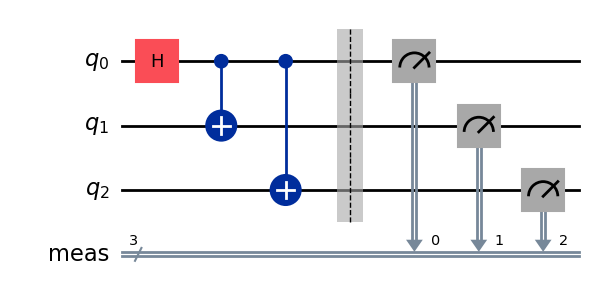

In [18]:
cirq = QuantumCircuit(3)

cirq.h(0)
cirq.cx(0, 1)
cirq.cx(0, 2)
cirq.measure_all()

cirq.draw("mpl")

# 3º Step: Transpile The Circuit Gates to The Set of Gates Available on The QPU

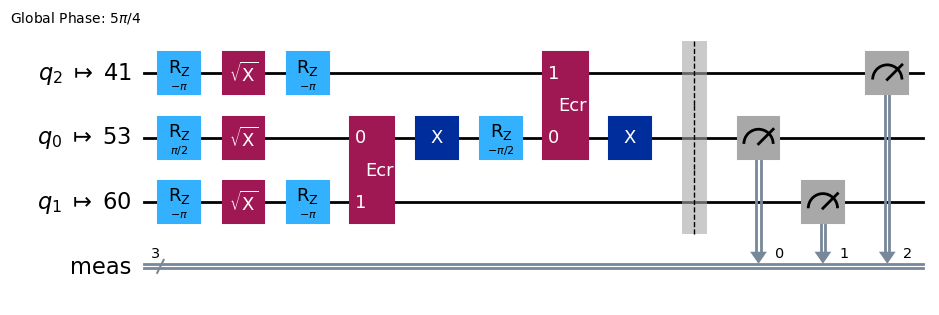

In [ ]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(cirq)
 
isa_circuit.draw("mpl", idle_wires=False)

# 4º Step: Run The Circuit On The QPU Using The Sampler Primitives

In [20]:
job = sampler.run([isa_circuit], shots=1024)
job_result = job.result()

In [26]:
counts = job_result[0].data.meas.get_counts()

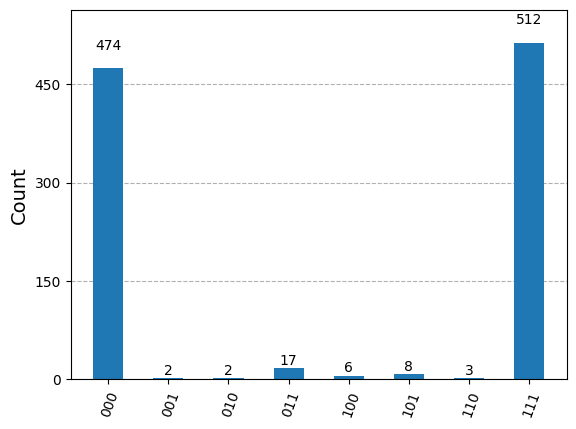

In [27]:
plot_histogram(counts)